In [1]:
import TNGFunctions as TNG
import PlotFunctions as plot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import MATH
import warnings
import os

from scipy.interpolate import interp1d
from astropy.cosmology import WMAP9 as cosmo
from astropy.cosmology import WMAP7
from matplotlib.lines import Line2D


plt.style.use('abhner.mplstyle')
np.seterr(divide='ignore') # ignore divide by zero


warnings.filterwarnings( "ignore")



In [2]:
# cosmological parameters
Omegam0 = 0.3089
h = 0.6774

#SIM TNG
SIMTNG = 'TNG50'

#Paths
dfTime = pd.read_csv(os.getenv("HOME")+'/TNG_Analyzes/SubhaloHistory/SNAPS_TIME.csv')
df_z0_Mstar_Range = TNG.extractDF('Sample', SIM=SIMTNG)
PaperII = TNG.extractDF('PaperII', SIM=SIMTNG)

# Fig. 1

BadFlag


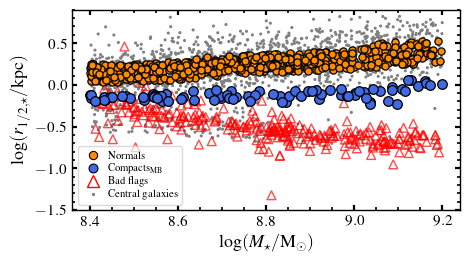

In [4]:
fig=plt.figure(facecolor='white')
plt.rcParams.update({'figure.figsize': (5, 2.6)})
X = np.transpose(np.array([df_z0_Mstar_Range.loc[df_z0_Mstar_Range.CentralSatellite == 'Central', 'logMstarRad_99'].values,
                           df_z0_Mstar_Range.loc[df_z0_Mstar_Range.CentralSatellite == 'Central', 'logHalfRadstar_99'].values]))
Masses = np.linspace(8.4, 9.2, 100)


plt.scatter(X[:,0],X[:,1],s=5,c='gray',ec='none')

# Main branch

# Normals

plt.scatter(PaperII.logMstarRad_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('BadFlag', SubfindID_99 = True))],
            PaperII.logHalfRadstar_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('BadFlag', SubfindID_99 = True))], marker = '^',
            s=40,c='none', ec = 'red', alpha = 0.7)


plt.scatter(PaperII.logMstarRad_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('NormalSatellite', SubfindID_99 = True))],
            PaperII.logHalfRadstar_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('NormalSatellite', SubfindID_99 = True))],
            s=4.5*6,c='darkorange', linewidths= 0.9)


plt.scatter(PaperII.logMstarRad_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('MBCSatellite', SubfindID_99 = True))],
            PaperII.logHalfRadstar_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('MBCSatellite', SubfindID_99 = True))],
            s=8*6,c='royalblue',  linewidths= .9)


columnspacing = 0.2
handletextpad = 0.4
labelspacing = 0.3
fontlegend= 13
framealpha= 0.7
alphaScater=0.8
quantile=0.28

custom_lines, label, ncol, mult = plot.Legend(
    ['NormalBlackLineScatter',  'MBCBlackLineScatter','BadFlagEmptyScatter', 'TNGrageCentralScatter'])
plt.legend(
    custom_lines, label, ncol=1, fontsize=mult*fontlegend, framealpha=framealpha, 
    columnspacing = columnspacing, handletextpad = handletextpad, labelspacing = labelspacing)

plt.ylim(-1.5, 0.9)
#plt.xlim(0, 10)
plt.tick_params(labelsize = 0.85 * 13)
plt.xlabel(r'$\log(M_\star/\mathrm{M}_\odot)$', fontsize = 13)
plt.ylabel(r'$\log(r_{1/2, \star}/\mathrm{kpc})$', fontsize = 13)


plt.savefig(os.getenv("HOME")+'/TNG_Analyzes/Figs/' + SIMTNG + '/PaperII_NOSB/PlotScatter/sizevsM_Classes.pdf')

# Fig. 2

Normal: 0.0304109732508513
MBC: 0.0
Normal: 0.3265849176490008
MBC: 0.0203916353759355
Normal: 0.9894606364575405
MBC: 0.4706830278021542


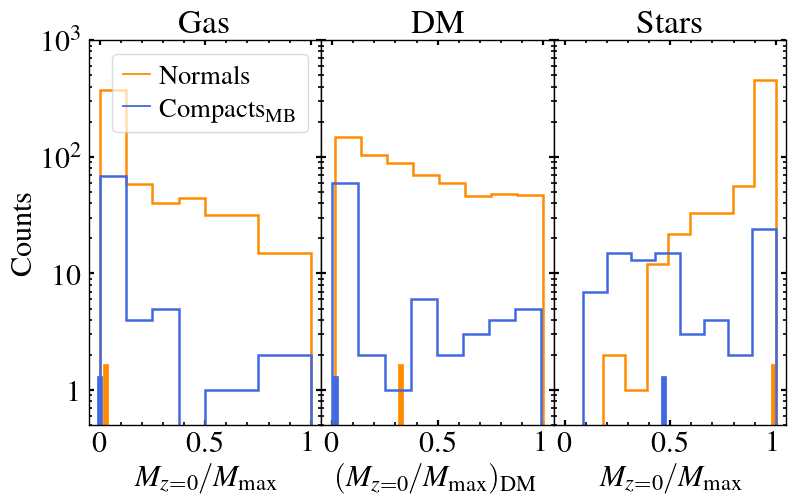

In [9]:
plot.PlotHist(['Normal',  'MBC'], 
              ['Mgas_Norm_Max_99',
             'MDM_Norm_Max_99', 'Mstar_Norm_Max_99'], ['Satellite'],  Type = 'z0',
               savepath='PaperII_NOSB/PlotHist',  savefigname='Gas', dfName='PaperII', SampleName='SubfindID_99', 
                density=False, 
                ColumnPlot = False, bins=[[8, 8, 8]], median=True,  legend = True, 
                lNum = 5, cNum = 3, GridMake = False,
                LegendNames = [[ 'Normal', 'MBC']], 
                xlimmin = [-0.05, -0.05, -0.05], xlimmax = [1.05, 1.05, 1.05],  
                legpositions = [[0, 0]], title = ['Gas', 'DM', 'Stars'],
                yscale = 'log',loc=['best'],TRANSPARENT = True, LookBackTime = True,
                fontlabel=22,  handlelength = 1,
                framealpha=0.7, handletextpad = 0.35)

# Fig. 3


 Type:  Satellite

 Type:  Satellite


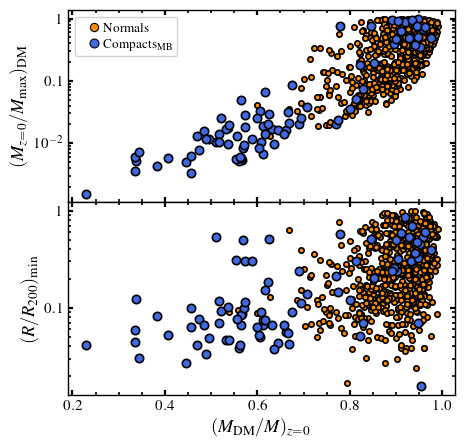

In [5]:
plot.PlotScatter(['Normal','MBC'], ['Satellite'], 'DMFrac_99', ['MDM_Norm_Max_99', 'rOverR200Min'],  Type='z0', snap=[99],
 title=False, medianBins=False, medianAll=False, xlabelintext=False, All=None,
                legend=True, LegendNames=[['NormalBlackLineScatter', 'MBCBlackLineScatter']],  TRANSPARENT = False, COLORBAR = None, medianDot = False, 
                alphaScater=1.,   alphaShade=0.3,  linewidth=1.2, 
                fontlabel=11,  
                m='o', msizet=4.5, quantile=0.95,framealpha = 0.85, q = 0.95,
                MarkerSizes = None,
                lNum = 2.5, cNum = 5, GridMake = False,
                #ylimmin = [1.9e-4], ylimmax = [0.99], xlimmin = [6e-3], xlimmax = [25],  
                legpositions = [[0, 0]],  
                columnspacing = 0.5, handletextpad = -0.3, labelspacing = 0.3, loc = ['best'],
                savepath='PaperII_NOSB/PlotScatter',  savefigname='DMFracMaxTot', dfName='PaperII', SampleName='Samples', cmap = 'inferno',
                bins=10, seed=16010504, mult = 4.1)

# Fig. 4


 Type:  SatelliteDMrich
MBC  X =  0.440298 Y =  0.503048
Normal  X =  0.440298 Y =  0.575981

 Type:  SatelliteDMpoor
MBC  X =  0.81671 Y =  1.201538
Normal  X =  0.5031995 Y =  0.584604


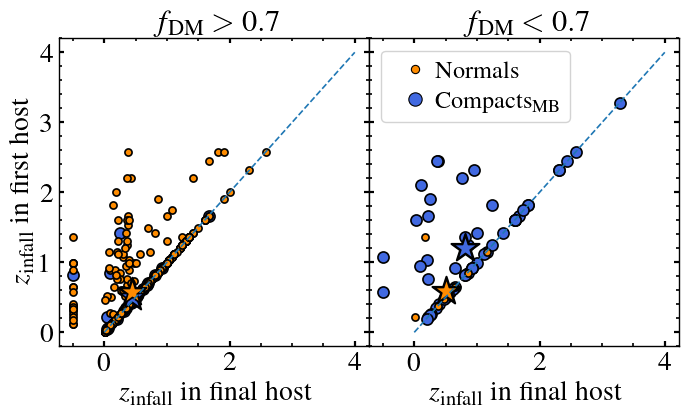

In [11]:
plot.PlotScatter([ 'MBC', 'Normal'], ['SatelliteDMrich', 'SatelliteDMpoor'], 'z_At_FinalEntry', 'z_At_FirstEntry',  Type='z0', snap=[99],
 title=['DMrich','DMpoor'],medianBins=False, medianAll=False, xlabelintext=False, All=None, 
                legend=True, LegendNames=[['NormalBlackLineScatter', 'MBCBlackLineScatter']],  TRANSPARENT = True,  medianDot = True, 
                alphaScater=1.,   alphaShade=0.3,  linewidth=1.2, 
                fontlabel=20,  msizeMult = 1.2,
                m='o', msizet=8, quantile=0.95,framealpha = 0.85, q = 0.95,
                MarkerSizes = None,
                lNum = 4, cNum = 4, GridMake = False,
                #ylimmin = [1.9e-4], ylimmax = [0.99], xlimmin = [6e-3], xlimmax = [25],  
                legpositions = [[1, 0]],  
                columnspacing = 0.5, handletextpad = -0.2, labelspacing = 0.3, loc = ['best'], EqualLine = True, EqualLineMin = 0, EqualLineMax = 4,
                savepath='PaperII_NOSB/PlotScatter',  savefigname='SnapEntry', dfName='PaperII', SampleName='Samples', cmap = 'Reds',
                bins=10, seed=16010504, mult = 6.1)

In [12]:
TNG.compare_Sample_key('z_At_FinalEntry', [['Normal_Satellite_DMpoor', 'MBC_Satellite_DMpoor']], dfName = 'PaperII')
print('\n')
TNG.compare_Sample_key('z_At_FirstEntry', [['Normal_Satellite_DMpoor', 'MBC_Satellite_DMpoor']], dfName = 'PaperII')

Normal_Satellite_DMpoor  and  MBC_Satellite_DMpoor
Medians:  0.503 0.834
Observed Test Statistic: 0.33089
Permutation Test P-Value: 0.25626


Normal_Satellite_DMpoor  and  MBC_Satellite_DMpoor
Medians:  0.585 1.202
Observed Test Statistic: 0.61693
Permutation Test P-Value: 0.09024


In [13]:
TNG.compare_Sample_key('z_At_FinalEntry', [['Normal_Satellite_DMrich', 'Normal_Satellite_DMpoor'],
                               ['MBC_Satellite_DMrich', 'MBC_Satellite_DMpoor']], dfName = 'PaperII')
print('\n')
TNG.compare_Sample_key('z_At_FirstEntry', [['Normal_Satellite_DMrich', 'Normal_Satellite_DMpoor'],
                               ['MBC_Satellite_DMrich', 'MBC_Satellite_DMpoor']], dfName = 'PaperII')


Normal_Satellite_DMrich  and  Normal_Satellite_DMpoor
Medians:  0.461 0.503
Observed Test Statistic: 0.04228
Permutation Test P-Value: 0.80094
MBC_Satellite_DMrich  and  MBC_Satellite_DMpoor
Medians:  0.461 0.834
Observed Test Statistic: 0.37303
Permutation Test P-Value: 0.03122


Normal_Satellite_DMrich  and  Normal_Satellite_DMpoor
Medians:  0.576 0.585
Observed Test Statistic: 0.00862
Permutation Test P-Value: 0.97254
MBC_Satellite_DMrich  and  MBC_Satellite_DMpoor
Medians:  0.503 1.202
Observed Test Statistic: 0.69849
Permutation Test P-Value: 0.00634


# Fig. 5


 Type:  SatelliteDMrich
NormalColorbar  X =  12.678106709677415 Y =  0.8318242795184916
MBCColorbar  X =  12.325108672633316 Y =  0.8934015055415652
SBCColorbar  X =  11.86998532035134 Y =  0.7165742964760767

 Type:  SatelliteDMpoor
NormalColorbar  X =  12.002092982783463 Y =  0.570578400285507
MBCColorbar  X =  13.00304864543152 Y =  0.42927219531658467
SBCColorbar  X =  12.389592312428416 Y =  0.4075293321703793


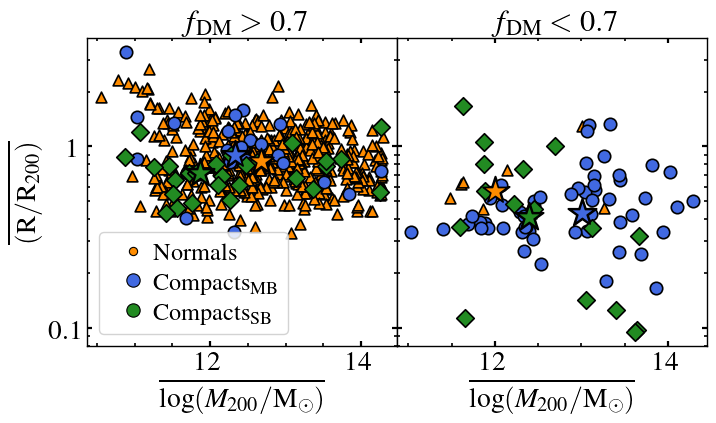

In [ ]:
plot.PlotScatter(['NormalColorbar','MBCColorbar'], ['SatelliteDMrich', 'SatelliteDMpoor'], 'M200Mean', ['rOverR200Mean_New'],  Type='z0', snap=[99],
 title=['DMrich','DMpoor'],medianBins=False, medianAll=False, xlabelintext=False, All=None, # COLORBAR = ['TimeInnerRegion'],
                legend=True, LegendNames=[['NormalBlackLineScatter', 'MBCBlackLineScatter']],  TRANSPARENT = True,  medianDot = True, 
                alphaScater=1.,   alphaShade=0.3,  linewidth=1.2, 
                fontlabel=20,  msizeMult = 1.2,
                m='o', msizet=10, quantile=0.95,framealpha = 0.85, q = 0.95,
                MarkerSizes = None,
                lNum = 4, cNum = 4, GridMake = False,
                #ylimmin = [1.9e-4], ylimmax = [0.99], xlimmin = [6e-3], xlimmax = [25],  
                legpositions = [[0, 0]],  
                columnspacing = 0.5, handletextpad = -0.2, labelspacing = 0.3, loc = ['best'], EqualLine = False, EqualLineMin = 0, EqualLineMax = 4,
                savepath='PaperII_NOSB/PlotScatter',  savefigname='Environment', dfName='PaperII', SampleName='Samples', cmap = 'rainbow',
                bins=10, seed=16010504, mult = 6.1)

In [14]:
TNG.compare_Sample_key('M200Mean', [['Normal_Satellite_DMpoor', 'MBC_Satellite_DMpoor']], dfName = 'PaperII')
print('\n')
TNG.compare_Sample_key('rOverR200Mean', [['Normal_Satellite_DMpoor', 'MBC_Satellite_DMpoor']], dfName = 'PaperII')

Normal_Satellite_DMpoor  and  MBC_Satellite_DMpoor
Medians:  12.002 13.003
Observed Test Statistic: 1.00096
Permutation Test P-Value: 0.01684


Normal_Satellite_DMpoor  and  MBC_Satellite_DMpoor
Medians:  0.629 0.414
Observed Test Statistic: 0.21441
Permutation Test P-Value: 0.01114


In [18]:
TNG.compare_Sample_key('M200Mean', [['Normal_Satellite_DMrich', 'Normal_Satellite_DMpoor'],
                               ['MBC_Satellite_DMrich', 'MBC_Satellite_DMpoor']], dfName = 'PaperII')
print('\n')
TNG.compare_Sample_key('rOverR200Min', [['Normal_Satellite_DMrich', 'Normal_Satellite_DMpoor'],
                               ['MBC_Satellite_DMrich', 'MBC_Satellite_DMpoor']], dfName = 'PaperII')
print('\n')
TNG.compare_Sample_key('rOverR200Mean_New', [['Normal_Satellite_DMrich', 'Normal_Satellite_DMpoor'],
                               ['MBC_Satellite_DMrich', 'MBC_Satellite_DMpoor']], dfName = 'PaperII')


Normal_Satellite_DMrich  and  Normal_Satellite_DMpoor
Medians:  12.678 12.002
Observed Test Statistic: 0.67601
Permutation Test P-Value: 0.07884
MBC_Satellite_DMrich  and  MBC_Satellite_DMpoor
Medians:  12.325 13.003
Observed Test Statistic: 0.67794
Permutation Test P-Value: 0.00896


Normal_Satellite_DMrich  and  Normal_Satellite_DMpoor
Medians:  0.246 0.125
Observed Test Statistic: 0.12114
Permutation Test P-Value: 0.2099
MBC_Satellite_DMrich  and  MBC_Satellite_DMpoor
Medians:  0.316 0.068
Observed Test Statistic: 0.24813
Permutation Test P-Value: 0.0


Normal_Satellite_DMrich  and  Normal_Satellite_DMpoor
Medians:  0.832 0.571
Observed Test Statistic: 0.26125
Permutation Test P-Value: 0.05234
MBC_Satellite_DMrich  and  MBC_Satellite_DMpoor
Medians:  0.893 0.429
Observed Test Statistic: 0.46413
Permutation Test P-Value: 0.0


# Fig. 6

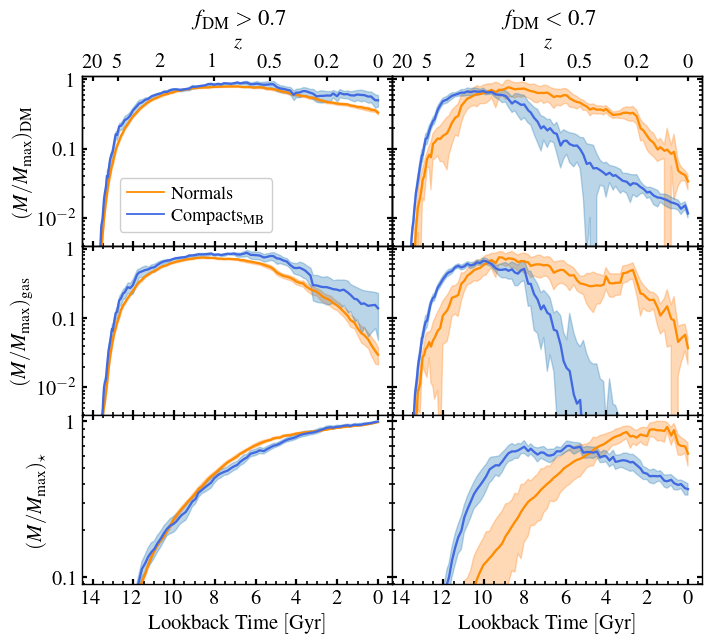

In [7]:
plot.PlotMedianEvolution(['Normal', 'MBC'], ['SatelliteDMrich', 'SatelliteDMpoor'],  ['MDM_Norm_Max',  'Mgas_Norm_Max', 'Mstar_Norm_Max'], 
                     Type='Evolution', Xparam=['Time'], title=['DMrich', 'DMpoor'], 
                        xlabelintext=False, lineparams=False,  LookBackTime = True, 
                        ColumnPlot=True, limaxis=True,  legend=True,  legendColumn = True, 
                        Transparent = True, Text = None, Pericenter = False, Supertitle = False, GridMake = False,
                        savepath='PaperII_NOSB/PlotMedianEvolution',  savefigname='DMpoorMass', dfName='PaperII', SampleName='SubfindID_99', 
                        Supertitle_Name = 'DM-rich',LegendNames=[['Normal', 'MBC']],
                        loc = [(0.12, 0.08), 'best', 'best'],  loctext = ['best'],
                        ylimmin = [0.004, 0.004, 0.09,], ylimmax = [1.1,1.1, 1.1], xlimmin = None, xlimmax = None,  
                        legpositions = [[0, 0]], 
                        lNum = 2.2, cNum = 4,
                        alphaShade=0.3,  linewidth=1.1, framealpha = 0.95,  fontlabel=15,   nboots=100,  
                        Supertitle_y = 0.99,  columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3, 
                        bins=10, seed=16040105)

# Fig. 7

SatelliteDMrich: -0.388616108614443
SatelliteDMpoor: 0.5099250288317605


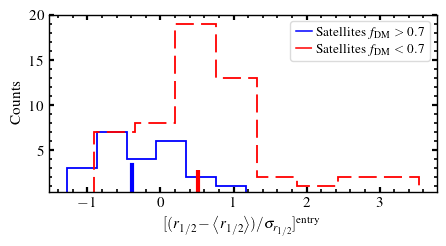

In [8]:
plot.PlotHist(['SatelliteDMrich', 'SatelliteDMpoor'], ['MBC'],
              ['deltaSize_at_Entry'],   Type = 'Sample',
               savepath='PaperII_NOSB/PlotHist',  savefigname='SizeDelta', dfName='PaperII', SampleName='SubfindID_99', 
                density=False, 
                ColumnPlot = True,  median=True,  legend = True,  legendColumn = True, GridMake = False,
                lNum = 2.3, cNum = 5, 
                LegendNames = [['SatelliteDMrich', 'SatelliteDMpoor']], legpositions = [[0, 0]], #xlabelintext = ['SBC', 'MBC'], 
                ylimmin = [0.4, 0.4], ylimmax = [20, 32], #xlimmin = [-0.1, 10.2, 0.08], xlimmax = [3.5, 14.9, 9],
                yscale = 'linear', TRANSPARENT = True, LookBackTime = True, loc = ['upper right'],
                fontlabel=11, linewidth=1.3,
                framealpha=0.7, handlelength = 1.2, handletextpad = 0.3)


# Fig. 8

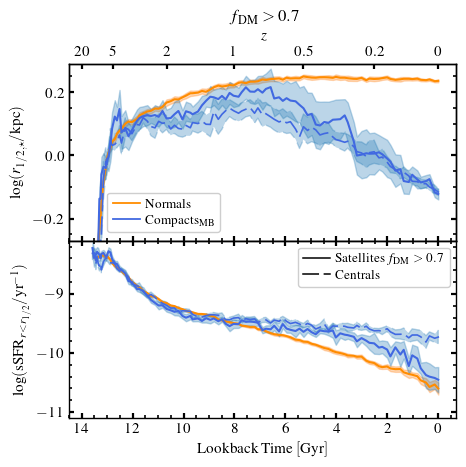

In [33]:
plot.PlotMedianEvolution(['NormalSatelliteDMrich', 'MBCSatelliteDMrich', 'MBCCentral'], [''],  ['SubhaloHalfmassRadType4',  'SubhalosSFRInHalfRad'], 
                     Type='Evolution', Xparam=['Time'], title=['DMrich'], 
                        xlabelintext=False, lineparams=False,  LookBackTime = True, 
                        ColumnPlot=True, limaxis=True,  legend=True,  legendColumn = True, 
                        Transparent = True, Text = None, Pericenter = False, Supertitle = False, GridMake = False,
                        savepath='PaperII_NOSB/PlotMedianEvolution',  savefigname='SizesSFR', dfName='PaperII', SampleName='SubfindID_99', 
                        Supertitle_Name = 'DM-rich',LegendNames=[['Normal', 'MBC'], ['SatelliteDMrichCO', 'CentralCO']],
                        loc = [(0.1, 0.05), 'best'],  loctext = ['best'],
                        ylimmin = [-0.27, -11.1], ylimmax = [0.29, -8.1], xlimmin = None, xlimmax = None,  
                        legpositions = [[0, 0], [0,1]], 
                        lNum = 2.3, cNum = 5,
                        alphaShade=0.3,  linewidth=1.1, framealpha = 0.95,  fontlabel=11,   nboots=100,  
                        Supertitle_y = 0.99, Softening = False, columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3, 
                        bins=10, seed=16040105)

# Fig. 9

SatelliteDMrich: -9.543069794774055
SatelliteDMpoor: -11.145625110067265
Central: -9.40184503502962


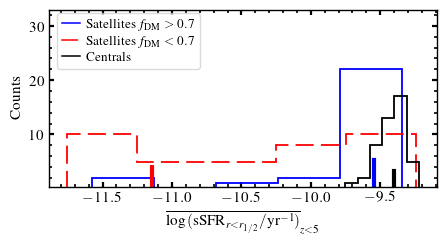

In [9]:
plot.PlotHist(['SatelliteDMrich', 'SatelliteDMpoor', 'Central'], ['MBC'],
              ['sSFRinHalfRadAfterz5'],   Type = 'Sample',
               savepath='PaperII_NOSB/PlotHist',  savefigname='sSFRCentrals', dfName='PaperII', SampleName='SubfindID_99', 
                density=False, 
                ColumnPlot = True, bins=[[5, 5, 6]], median=True,  legend = True,  legendColumn = True, GridMake = False,
                lNum = 2.3, cNum = 5,   linewidth=1.3,
                LegendNames = [['SatelliteDMrich', 'SatelliteDMpoor', 'Central']], legpositions = [[0, 0]], loc = [(0.02, 0.665)],
                ylimmin = [0.4, 0.4], ylimmax = [33, 32], #xlimmin = [-0.1, 10.2, 0.08], xlimmax = [3.5, 14.9, 9],
                yscale = 'linear', TRANSPARENT = True, LookBackTime = True, 
                fontlabel=11, handlelength = 1.3,
                framealpha=0.7, handletextpad = 0.45)

In [16]:
TNG.compare_Sample_key('sSFRinHalfRadAfterz5', [['MBC_Satellite_DMrich', 'MBC_Central'],
                               ['SBC_Satellite_DMrich', 'SBC_Central'],
                               ['MBC_Satellite_DMpoor', 'MBC_Central'],
                               ['SBC_Satellite_DMpoor', 'SBC_Centralr']], dfName = 'PaperII')


MBC_Satellite_DMrich  and  MBC_Central
Medians:  -9.543 -9.402
Observed Test Statistic: 0.14122
Permutation Test P-Value: 0.0001
SBC_Satellite_DMrich  and  SBC_Central
Medians:  -9.374 -9.335
Observed Test Statistic: 0.03908
Permutation Test P-Value: 0.018
MBC_Satellite_DMpoor  and  MBC_Central
Medians:  -11.146 -9.402
Observed Test Statistic: 1.74378
Permutation Test P-Value: 0.0
SBC_Satellite_DMpoor  and  SBC_Centralr
Medians:  -10.192 -9.335
Observed Test Statistic: 0.85722
Permutation Test P-Value: 0.0


# Fig. 10

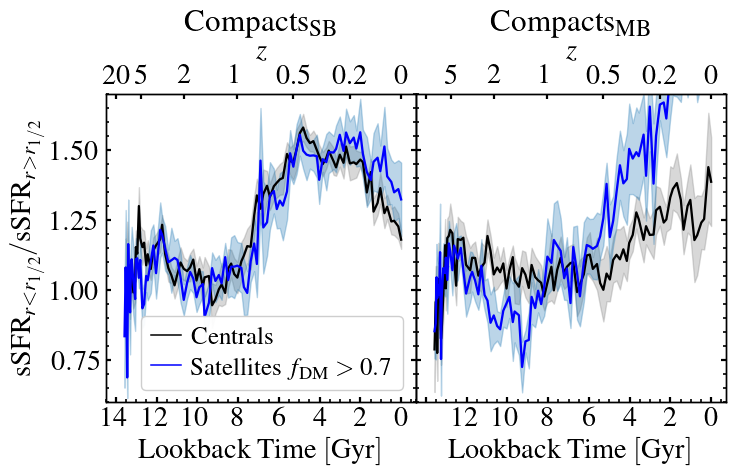

In [ ]:
plot.PlotMedianEvolution(['Central', 'SatelliteDMrich'], ['SBC', 'MBC'],  ['sSFRCoreRatio'], 
                     Type='Evolution', Xparam=['Time'], title=['SBC', 'MBC'], 
                        xlabelintext=False, lineparams=False,  LookBackTime = True, 
                        ColumnPlot=True, limaxis=True,  legend=True,  legendColumn = True, 
                        Transparent = True, Text = None, Pericenter = False, Supertitle = False, GridMake = False,
                        savepath='PaperII_NOSB/PlotMedianEvolution',  savefigname='sSFRRatioCentrals', dfName='PaperII', SampleName='SubfindID_99', 
                        Supertitle_Name = 'DM-rich',LegendNames=[['Central', 'SatelliteDMrich']],
                        loc = ['best'],  loctext = ['best'],
                        ylimmin = [0.6], ylimmax = [1.7], xlimmin = None, xlimmax = None,
                        legpositions = [[0, 0]],
                        lNum = 4, cNum = 4, SmallerScale= True,
                        alphaShade=0.3,  linewidth=1.1, framealpha = 0.95,  fontlabel=20.5,   nboots=100,  
                        Supertitle_y = 0.99,  columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3,  handlelength = 1.2, 
                        bins=10, seed=16040105)


# Fig. 11

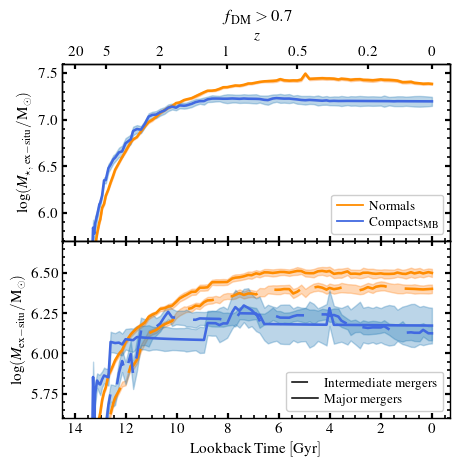

In [43]:
plot.PlotMedianEvolution(['Normal', 'MBC'], ['SatelliteDMrich'],  [['StellarMassExSitu'], ['StellarMassExSituIntermediate', 'StellarMassExSituMajor']], 
                     Type='Evolution', Xparam=['Time'], title=['DMrich', 'DMpoor'], 
                        xlabelintext=False, lineparams=True,  LookBackTime = True, 
                        ColumnPlot=True, limaxis=True,  legend=True,  legendColumn = True, 
                        Transparent = True, Text = None, Pericenter = False, Supertitle = False,  GridMake = False,
                        savepath='PaperII_NOSB/PlotMedianEvolution',  savefigname='ExSitu', dfName='PaperII', SampleName='SubfindID_99', 
                        Supertitle_Name = 'DM-rich',LegendNames=[['Normal', 'MBC'], ['StellarMassExSituIntermediate', 'StellarMassExSituMajor']],
                        loc = ['best', 'best'],  loctext = ['best'],
                        ylimmin = [5.7, 5.6], ylimmax = [7.6, 6.7],
                        legpositions = [[0, 0], [0 ,1]], SmallerScale = True, EntryMedian = False,
                        lNum = 2.3, cNum = 5,
                        alphaShade=0.3,  linewidth=1.1, framealpha = 0.95,  fontlabel=11,   nboots=100,  
                        Supertitle_y = 0.99,  columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3, 
                        bins=10, seed=16040105)

# Fig. 12

In [ ]:
IDs_SBCSatelliteDMrich = np.array([   91,    156,    165,  63918,  96799, 167427, 198195, 198199,
       264900, 319740, 324134, 355736, 379807, 439101, 440412, 468596,
       489208, 499708, 513846, 531321, 570842, 573063, 574616, 592022,
       616015, 618581, 625186, 629892, 649988, 661261, 667085, 668241,
       671097, 684712, 692883, 694489, 697154, 724892, 725997, 770775,
       804308])

IDs_SBCSatelliteDMpoor = np.array([63990,  64002,  96853, 117357, 229992, 229996, 294887, 294895,
                                   358627, 422770, 428191, 500583, 516761, 602132, 602133, 603556])

IDs_MBCSatelliteDMrich = np.array([550,  63973,  96789, 117311, 220616, 229958, 264932, 289394,
       300918, 307497, 307502, 342468, 372756, 419621, 422762, 435755,
       445628, 450924, 487746, 488533, 489207, 571909, 579511, 590015,
       597142, 681818, 701373, 814011, 823293])

IDs_MBCSatelliteDMpoor = np.array([232,    261,    281,    300,    319,    333,  63993,  64081,
        64129,  96941, 117464, 144008, 144098, 167499, 185005, 185058,
       208883, 220626, 242863, 253897, 253905, 253965, 264911, 264972,
       275601, 282802, 282807, 289444, 307510, 319738, 319743, 377662,
       386293, 394628, 404834, 421566, 421567, 422763, 425726, 432119,
       457435, 467420, 482157, 502998, 530853, 536657, 545439, 549748,
       549750, 558069, 571075, 571910, 588180, 647769])

IDs_NormalSatelliteDMrich = np.array([333431, 677786, 143950,    203,    147, 775527, 198247, 117291,
       427216, 198231, 770462, 117299, 386274, 471252, 800643,  63957,
       594247, 465257, 253882, 763684, 574885, 837220, 143967, 184962,
          423, 508541, 472552,    214, 749432, 184980,  63939, 184966,
       435760, 414921,    181, 345881, 229952, 282799, 264901, 117426,
       184984, 117314,  64009, 184982, 294884, 229984, 208826, 494014,
       433290, 198237])

IDs_NormalSatelliteDMpoor = np.array([184957, 220633, 338455, 436937, 560083, 586424, 602131, 603005])

#%%
fontlabel = 16
nboot = 5000
nbins = 30
plt.rcParams.update({'figure.figsize': (4*2, 4*2.3)})
fig = plt.figure()
gs = fig.add_gridspec(3, 2, hspace=0, wspace=0)
axs = gs.subplots(sharex='col', sharey='row')
Names = [r'Normals', r'Compacts$_\mathrm{MB}$']
rmin = 0.06
rmax = 35

for j, PartType in enumerate(['PartType0', 'PartType0', 'PartType4']):
    if j == 0:
        velPlot = True
    else:
        velPlot = False
    for linplot, IDs in enumerate([IDs_NormalSatelliteDMrich, IDs_MBCSatelliteDMrich]):
        
        dFHalfStar = TNG.extractDF('SubhaloHalfmassRadType4')
        dFHalfGasRad = TNG.extractDF('SubhaloHalfmassRadType0')
        
        
        #SNAP FIRST
        SnapsFirst = []
        for l, ID in enumerate(IDs):
            if ID == 603556 or ID == 602133:
                continue
            snapFirstEntry = PaperII.Snap_At_FirstEntry.loc[PaperII.SubfindID_99 == ID].values[0]
            if np.isnan(snapFirstEntry) or snapFirstEntry < 0:
                snapFirstEntry = 67
            snap = dfTime.loc[abs(dfTime.Age - dfTime.loc[dfTime.Snap == snapFirstEntry, 'Age'].values[0]) < 1.5, 'Snap'].values[-1]
            if snap < 17:
                snap = 17
            SnapsFirst.append(int(snap))
             
        xFirst, yFirst, yerrFirst, massFirst, xIDsFirst, yIDFirst, massIDsFirst, notIndex = plot.MakeMedianAndIDs(SnapsFirst, IDs, rmin, rmax, nbins, PaperII, PartType = PartType, velPlot= velPlot)
      
        #First
        colors = plt.cm.Blues(np.linspace(0,1,len(yIDFirst)))
        plot.MakeLines(j, axs[j][linplot], yIDFirst, xIDsFirst, IDs, notIndex, colors)
          
        #SNAP FIRST
        Snaps = []
        for l, ID in enumerate(IDs):
            if ID == 603556 or ID == 602133:
                continue
            snapFirstEntry = PaperII.Snap_At_FirstEntry.loc[PaperII.SubfindID_99 == ID].values[0]
            if np.isnan(snapFirstEntry) or snapFirstEntry < 0:
                snapFirstEntry = 67
            Snaps.append(int(snapFirstEntry))
             
        xSecond, ySecond, yerrSecond, massSecond, xIDsSecond, yIDSecond, massIDsSecond, notIndex = plot.MakeMedianAndIDs(Snaps, IDs, rmin, rmax, nbins, PaperII, PartType = PartType, velPlot= velPlot)
      
        #Second
        colors = plt.cm.Greens(np.linspace(0,1,len(yIDSecond)))
        plot.MakeLines(j, axs[j][linplot], yIDSecond, xIDsSecond, IDs, notIndex, colors)
          
        #SNAP Final
        SnapsFinal = []
        for l, ID in enumerate(IDs):
            if ID == 603556 or ID == 602133:
                continue
            snapFirstEntry = PaperII.Snap_At_FirstEntry.loc[PaperII.SubfindID_99 == ID].values[0]
            if np.isnan(snapFirstEntry) or snapFirstEntry < 0:
                snapFirstEntry = 67
            if linplot == 1:
                snap = dfTime.loc[abs(dfTime.Age - dfTime.loc[dfTime.Snap == snapFirstEntry, 'Age'].values[0]) < 2, 'Snap'].values[0]
            else:
                snap = 99 #
            SnapsFinal.append(int(snap))
             
        xFinal, yFinal, yerrFinal, massFinal, xIDsFinal, yIDsFinal, massIDsFinal, notIndex = plot.MakeMedianAndIDs(SnapsFinal, IDs, rmin, rmax, nbins, PaperII, PartType = PartType, velPlot= velPlot)
        
        colors = plt.cm.Reds(np.linspace(0,1,len(yIDsFinal)))
        plot.MakeLines(j, axs[j][linplot], yIDsFinal, xIDsFinal, IDs, notIndex, colors)

    
        if j == 1 or j == 2:
            
            axs[j][linplot].fill_between(xFirst, (yFirst - yerrFirst)*xFirst**2, (yFirst + yerrFirst)*xFirst**2, 
                                        color='tab:red',  alpha=0.3) 
            axs[j][linplot].fill_between(xSecond, (ySecond - yerrSecond)*xSecond**2, (ySecond + yerrSecond)*xSecond**2, 
                                        color='tab:green',  alpha=0.3) 
            axs[j][linplot].fill_between(xFinal, (yFinal - yerrFinal)*xFinal**2, (yFinal + yerrFinal)*xFinal**2, 
                                        color='tab:blue',  alpha=0.3) 
            
            axs[j][linplot].plot(xFirst , yFirst*xFirst**2, color = 'red', lw = 1.5, label = r'$t_\mathrm{entry} - 2 \, \mathrm{[Gyr]}$')
   
            axs[j][linplot].plot(xSecond , ySecond*xSecond**2, color = 'green', lw = 1.5, label = r'$t_\mathrm{entry}$')
            
            axs[j][linplot].plot(xFinal , yFinal*xFinal**2, color = 'blue', lw = 1.5, label = r'$t_\mathrm{entry} + 2 \, \mathrm{[Gyr]}$')
          
        else:
            axs[j][linplot].fill_between(xFirst, (yFirst - yerrFirst), (yFirst + yerrFirst), 
                                        color='tab:red',  alpha=0.3) 
            axs[j][linplot].fill_between(xSecond, (ySecond - yerrSecond), (ySecond + yerrSecond), 
                                        color='tab:green',  alpha=0.3) 
            axs[j][linplot].fill_between(xFinal, (yFinal - yerrFinal), (yFinal + yerrFinal), 
                                        color='tab:blue',  alpha=0.3) 
            
            
            axs[j][linplot].plot(xFirst , yFirst, color = 'red', lw = 1.5, label = r'$t_\mathrm{entry} - 2 \, \mathrm{[Gyr]}$')
            axs[j][linplot].plot(xSecond , ySecond, color = 'green', lw = 1.5, label = r'$t_\mathrm{entry}$')
            axs[j][linplot].plot(xFinal , yFinal, color = 'blue', lw = 1.5, label = r'$t_\mathrm{entry} + 2 \, \mathrm{[Gyr]}$')
          
        
        if j == 0:
            axs[j][linplot].set_title(Names[linplot], fontsize=1.1*fontlabel)
        
        if j != 0 :
            axs[j][linplot].set_yscale('log')

        axs[j][linplot].set_xscale('log')
        
        axs[j][linplot].set_xlim(0.2, 75)

        if j == 0:
            axs[j][linplot].set_ylim(-100, 10)
        elif j == 1:
            axs[j][linplot].set_ylim(5e5, 5e7)

        else:
            axs[j][linplot].set_ylim(5e5, 2e8)
        
        if j == 2:
            axs[j][linplot].tick_params(axis='x', labelsize=0.99*fontlabel)
    
        #axs[0][linplot].axhline(np.nansum(massEntry[massEntry > 0]) / 2., ls = '--', color = 'black')
    
    
        if linplot == 0:
            axs[j][linplot].tick_params(axis='y', labelsize=0.99*fontlabel)
            if j == 2:
                axs[j][linplot].set_ylabel(r'$\rho_{\star} (r) r^2  \; \, \, [\mathrm{M_\odot  \; kpc^{-1}}]$', fontsize=fontlabel)
            elif j == 1:
                axs[j][linplot].set_ylabel(r'$\rho_{\mathrm{gas}} (r) r^2  \; \, \, [\mathrm{M_\odot  \; kpc^{-1}}]$', fontsize=fontlabel)
            else:
                axs[j][linplot].set_ylabel( r'$v_\mathrm{r, \; gas} (r) \, \, [\mathrm{km \, s}^{-1}]$', fontsize=fontlabel)

        if j == 2:
            axs[j][linplot].set_xlabel(r'$r  \; [\mathrm{kpc}]$', fontsize=fontlabel)
        
        
        if j != 0:
            axs[j][linplot].yaxis.set_major_formatter(
                plot.FuncFormatter(plot.format_func_loglog))
        axs[j][linplot].xaxis.set_major_formatter(
            plot.FuncFormatter(plot.format_func_loglog))
        axs[0][0].legend(fontsize=0.9*fontlabel, framealpha = 0.4)

plt.savefig(os.getenv("HOME")+'/TNG_Analyzes/Figs/TNG50/PaperII_NOSB/ProfilesTest.pdf', bbox_inches='tight')    
#plt.ylim(- 0.99, 0.99)


Doesn't have  PartType0  at snap:  89
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99


# Fig. 13


 Type:  SatelliteDMpoorLoseTheirGas
MBC


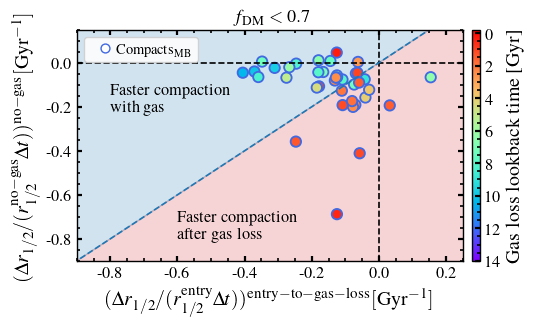

In [5]:
plot.PlotScatter(['MBC'], ['SatelliteDMpoorLoseTheirGas'], 'Decrease_Entry_To_NoGas_Norm_Delta', 'Decrease_NoGas_To_Final_Norm_Delta',  Type='z0', snap=[99],
 title=['DMpoor'], medianBins=False, medianAll=False, xlabelintext=False, All=None, GridMake = False,
                legend=True, LegendNames=[['MBCEmptyScatter']],  TRANSPARENT = False,  
                COLORBAR = ['SnapLostGas'], 
                cmap = 'rainbow',
                medianDot = False, 
                alphaScater=1.,  linewidth=1.2, 
                fontlabel=12,
                m='o', msizet=7, quantile=0.95,framealpha = 0.85, q = 0.95,
                MarkerSizes = None,
                lNum = 3, cNum = 6, EqualLine = True, EqualLineMin = -1., EqualLineMax = 0.3
                ,
                ylimmin = [-0.9], ylimmax = [0.15], xlimmin = [-0.9], xlimmax = [0.25],  
                legpositions = [[0, 0]],
                columnspacing = 0.5, handletextpad = -0.2, labelspacing = 0.3, loc = ['best'],
                savepath='PaperII_NOSB/PlotScatter',  savefigname='DeltaR_Orb', dfName='PaperII', SampleName='Samples',
                bins=10, seed=16010504, mult = 4.1)

# Fig. 14

In [ ]:
MBCIDs = np.array([   232,    261,    281,    300,    319,    333,  63993,  64081,
        64129,  96941, 117464, 144008, 144098, 167499, 185005, 185058,
       208883, 220626, 242863, 253897, 253905, 253965, 264911, 264972,
       275601, 282802, 282807, 289444, 307510, 319738, 319743, 377662,
       386293, 394628, 404834, 421566, 421567, 422763, 425726, 432119,
       457435, 467420, 482157, 502998, 530853, 536657, 545439, 549748,
       549750, 558069, 571075, 571910, 588180, 647769])

fontlabel = 11
nboot = 5000
nbins = 25
plt.rcParams.update({'figure.figsize': (5, 4)})
fig = plt.figure()
gs = fig.add_gridspec(2, 1, hspace=0, wspace=0)
axs = gs.subplots(sharex='col', sharey='row')
Names = [r'Compacts$_\mathrm{MB}$']
rmin = 0.1
rmax = 35
for linplot, IDs in enumerate([ MBCIDs]):
    
    dFHalfStar = TNG.extractDF('SubhaloHalfmassRadType4')
    dFHalfGasRad = TNG.extractDF('SubhaloHalfmassRadType0')
    yIDsEntry = np.array([])
    massIDsEntry = np.array([])
    xIDsEntry = np.array([])
    notIndex = np.array([])
    for l, ID in enumerate(IDs):
        print(ID)
        if ID == 603556 or ID == 602133 :
            continue
        snap = PaperII.Snap_At_FirstEntry.loc[PaperII.SubfindID_99 == ID].values[0]
        if np.isnan(snap):
            continue
        snap = int(snap)
        print('snap: ', snap)
        yrad, rad, mass = TNG.MakeDensityProfileMean(snap, ID, rmin, rmax, nbins)
        
        if len(yrad) == 1 or (ID == 603556 or ID == 602133):
            notIndex = np.append(notIndex, l)
            continue
        if l == 0 or len(yIDsEntry) == 0:
            yIDsEntry = np.append(yIDsEntry, yrad)
            xIDsEntry = np.append(xIDsEntry, rad)
            massIDsEntry = np.append(massIDsEntry, mass)
    
        else:
            yIDsEntry = np.vstack((yIDsEntry, yrad))
            massIDsEntry = np.vstack((massIDsEntry, mass))
            xIDsEntry = np.vstack((xIDsEntry, rad))
           
    
        Rvalues = xIDsEntry.T
        Values = yIDsEntry.T
        Masses = massIDsEntry.T

    x = np.array([])
    y = np.array([])
    mass = np.array([])
    
    
    
    if len(Values) > 0:
        if len(Values.shape) > 1:
            for k, value in enumerate(Values):
                x = np.append(x, np.nanmedian(Rvalues[k]))
                y = np.append(y, np.nanmedian(value))
                mass = np.append(mass, np.nanmedian(Masses[k]))
        else:
            x = Rvalues
            y = Values
            mass = Masses

    else:
        x = np.nan
        y = np.nan
        mass = np.nan
            
    xEntry = x
    yEntry = y
    massEntry = mass
      
    yIDs = np.array([])
    xIDs = np.array([])
    massIDs = np.array([])


    for l, ID in enumerate(IDs):  
     
        snap = 99
        yrad, rad, mass = TNG.MakeDensityProfileMean(snap, ID, rmin, rmax, nbins)
        if len(yrad) == 1 or (ID == 603556 or ID == 602133):
            notIndex = np.append(notIndex, l)
            continue
        if l == 0 or len(yIDs) == 0:
            yIDs = np.append(yIDs, yrad)
            xIDs = np.append(xIDs, rad)
            massIDs = np.append(massIDs, mass)

    
        else:
            yIDs = np.vstack((yIDs, yrad))
            xIDs = np.vstack((xIDs, rad))
            massIDs = np.vstack((massIDs, mass))

        Rvalues = xIDs.T
        Values = yIDs.T
        Masses = massIDs.T

    x = np.array([])
    y = np.array([])
    mass = np.array([])
    
    
    
    if len(Values) > 0:
        if len(Values.shape) > 1:
            for k, value in enumerate(Values):
                x = np.append(x, np.nanmedian(Rvalues[k]))
                y = np.append(y, np.nanmedian(value))
                mass = np.append(mass, np.nanmedian(Masses[k]))
        else:
            x = Rvalues
            y = Values
            mass = Masses

    else:
        x = np.nan
        y = np.nan
        mass = np.nan
            
    x99 = x
    y99 = y
    mass99 = mass



    colors = plt.cm.Blues(np.linspace(0,1,len(yIDsEntry)))
    k = 0
    for l, ID in enumerate(IDs):
        if l in notIndex:
            continue
        value = yIDsEntry[k]
        axs[0].plot(xIDsEntry[k][massIDsEntry[k] > 0] , np.nancumsum(massIDsEntry[k][massIDsEntry[k] > 0])  , 
                             lw = 0.55,  alpha = 0.4, color = colors[k])

        axs[1].plot(xIDsEntry[k][value > 0] , value[value > 0] * xIDsEntry[k][value > 0]**2., 
                             lw = 0.55,  alpha = 0.4,  color = colors[k])
        
        k = k+ 1

     
    colors = plt.cm.Reds(np.linspace(0,1,len(yIDs)))
    k = 0
    for l, ID in enumerate(IDs):
        if l in notIndex:
            continue
        value = yIDs[k]
        axs[0].plot(xIDs[k][massIDs[k] > 0] , np.nancumsum(massIDs[k][massIDs[k] > 0]) , 
                             lw = 0.55, alpha = 0.4,  color = colors[k])   
        axs[1].plot(xIDs[k][value > 0] , value[value > 0] * xIDs[k][value > 0]**2., 
                             lw = 0.55,alpha = 0.4,  color = colors[k])  
        
        k = k + 1

    axs[1].plot(xEntry , yEntry*xEntry**2, color = 'blue', lw = 1.75, label = r'$z_\mathrm{entry}$')
    axs[1].plot(x99 , y99*x99**2, color = 'red', lw = 1.8, label = r'$z = 0$')   
  
    axs[0].plot(xEntry[massEntry > 0] , np.nancumsum(massEntry[massEntry > 0]) , color = 'blue', lw = 1.75, label = r'$z_\mathrm{Entry}$')
    axs[0].plot(x99[mass99 > 0] , np.nancumsum(mass99[mass99 > 0]), color = 'red', lw = 1.75, label = r'$z = 0$')     
  
    
    axs[0].set_title(Names[linplot], fontsize=1.1*fontlabel)
    axs[0].set_xscale('log')
    axs[0].set_yscale('log')
    axs[1].set_yscale('log')
    
    axs[0].set_xlim(0.2, 75)
    axs[1].set_xlim(0.2, 75)
    axs[0].set_ylim(2e6, 6e9)
    axs[1].set_ylim(2e4, 2e8)
    
    axs[1].tick_params(axis='x', labelsize=0.99*fontlabel)

    axs[0].axhline(np.nansum(massEntry[massEntry > 0]) / 2., ls = '--', color = 'black')


    if linplot == 0:
        axs[1].tick_params(axis='y', labelsize=0.99*fontlabel)
        axs[0].set_ylabel(r'$M_\star (<r) \; [\mathrm{M}_\odot]$', fontsize=fontlabel)
        axs[1].set_ylabel(r'$\rho_{\star} (r) r^2  \; \, \, [\mathrm{M_\odot  \; kpc^{-1}}]$', fontsize=fontlabel)
    axs[1].set_xlabel(r'$r  \; [\mathrm{kpc}]$', fontsize=fontlabel)
    
    
    axs[1].yaxis.set_major_formatter(
        plot.FuncFormatter(plot.format_func_loglog))
    axs[0].yaxis.set_major_formatter(
        plot.FuncFormatter(plot.format_func_loglog))
    axs[1].xaxis.set_major_formatter(
        plot.FuncFormatter(plot.format_func_loglog))
    axs[0].legend(handlelength = 1.2 ,fontsize=0.9*fontlabel, framealpha = 0.4)

plt.savefig(os.getenv("HOME")+'/TNG_Analyzes/Figs/TNG50/PaperII_NOSB/Profiles.pdf', bbox_inches='tight')    
#plt.ylim(- 0.99, 0.99)



# Fig. 15


 Type:  SatelliteDMpoor
MBC


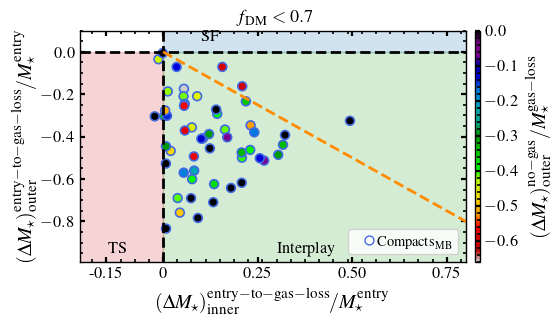

In [4]:
plot.PlotScatter(['MBC'], ['SatelliteDMpoor'], 'MassIn_Infall_to_GasLost', 'MassAboveAfter_Infall_to_GasLost',  Type='z0', snap=[99],
 title=['DMpoor'], medianBins=False, medianAll=False, xlabelintext=False, All=None, GridMake = False,
                legend=True, LegendNames=[['MBCEmptyScatter']],  TRANSPARENT = False,  COLORBAR = ['MassAboveAfterInfall_Lost'], 
                cmap = 'nipy_spectral_r',
                medianDot = False, 
                alphaScater=1.,    linewidth=1.2, 
                fontlabel=12,
                m='o', msizet=4.5, quantile=0.95,framealpha = 0.85, q = 0.95,
                MarkerSizes = None,
                lNum = 3, cNum = 6,
                ylimmin = [-0.99], ylimmax = [0.1], xlimmin = [-0.22], xlimmax = [0.8],  
                legpositions = [[0, 0]],
                columnspacing = 0.5, handletextpad = -0.4, labelspacing = 0.3, loc = ['best'],
                savepath='PaperII_NOSB/PlotScatter',  savefigname='MassIn_Out', dfName='PaperII', SampleName='Samples',
                bins=10, seed=16010504, mult = 4.1)

# Fig. 16

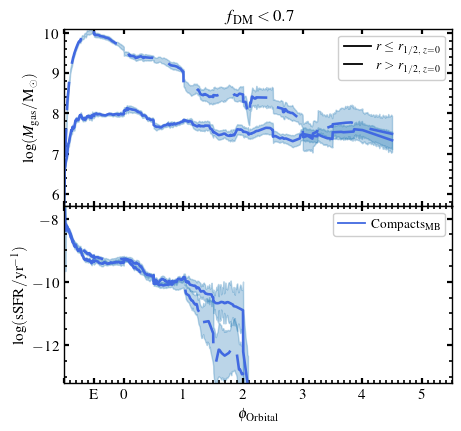

In [5]:
plot.PlotMedianEvolution(['MBC'], ['SatelliteDMpoor'],  [['GasMass_In_TrueRhpkpc', 'GasMass_Above_TrueRhpkpc'], ['sSFR_In_TrueRhpkpc', 'sSFR_Above_TrueRhpkpc']], 
                     Type='Evolution', Xparam=['Time'], title=['DMpoor'], PhasingPlot = True, xPhaseLim = 5,
                        xlabelintext=False, lineparams=True,  LookBackTime = True, 
                        ColumnPlot=True, limaxis=True,  legend=True,  legendColumn = True, 
                        Transparent = True, Text = None, Pericenter = False, Supertitle = False, GridMake = False,
                        savepath='PaperII_NOSB/PlotMedianEvolution',  savefigname='GasInnerOuterTrue', dfName='PaperII', SampleName='SubfindID_99', 
                        Supertitle_Name = 'DM-rich',LegendNames=[ ['GasMass_In_TrueRhpkpc', 'GasMass_Above_TrueRhpkpc'], [ 'MBC']],
                        loc = ['best', 'best' ],  loctext = ['best', 'best'],
                        legpositions = [[0, 0], [0,1]],
                        lNum = 2.3, cNum = 5,
                        ylimmin = [5.7, -13.2], ylimmax = [10.1, -7.6],
                        alphaShade=0.3,  linewidth=1.1, framealpha = 0.95,    fontlabel=11,   nboots=100,  
                        Supertitle_y = 0.99,  columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3, 
                        bins=10, seed=16040105)

In [ ]:

def _to_np(a):
    return np.asarray(a, dtype=float)

def _align_xy(x, y, e=None):
    """
    Alinha x, y (e opcionalmente e) pelo menor comprimento.
    Evita erros do tipo: boolean index ... dimension mismatch.
    """
    x = _to_np(x)
    y = _to_np(y)
    n = min(len(x), len(y))
    x = x[:n]
    y = y[:n]
    if e is not None:
        e = _to_np(e)[:n]
        return x, y, e
    return x, y, None

def PlotMedianEvolutionTwinY_OnePanel(
    names,
    columns,
    gas_params,          # ex.: ['GasMass_In_TrueRhpkpc','GasMass_Above_TrueRhpkpc']
    ssfr_params,         # ex.: ['sSFR_In_TrueRhpkpc','sSFR_Above_TrueRhpkpc']
    region_labels=None,  # ex.: ['In TrueRh','Above TrueRh']  (mesmo tamanho de gas_params)
    region_linestyles=None,  # ex.: ['solid','dashed']
    Type='Evolution',
    PhasingPlot=False,
    xPhaseLim=3,
    LookBackTime=True,
    Transparent=True,
    savepath='PlotMedianEvolutionTwinY',
    savefigname='fig_twin_onepanel',
    dfName='Sample',
    Name='Name',
    SampleName='SubfindID_99',
    # estilo variável->cor
    color_gas='tab:blue',
    color_ssfr='tab:orange',
    alphaShade=0.25,
    linewidth=1.1,
    fontlabel=13,
    multtick=0.95,
    framealpha=0.95,
    GridMake=False,
    # limites
    ylim_gas=None,    # tuple (ymin,ymax) ou None
    ylim_ssfr=None,   # tuple (ymin,ymax) ou None
    # legenda
    legend=True,
    legend_loc='best',
    nboots=100,
    seed=16040105,
):
    """
    Um painel só:
      - GasMass (eixo esquerdo, azul) com duas curvas (In/Above) diferenciadas por linestyle.
      - sSFR    (eixo direito, laranja) com duas curvas (In/Above) diferenciadas por linestyle.
    """

    np.random.seed(seed)

    # checks básicos
    if Type != 'Evolution':
        raise NotImplementedError("Este script está focado em Type='Evolution'.")

    if type(names) is not list and type(names) is not np.ndarray:
        names = [names]
    if type(columns) is not list and type(columns) is not np.ndarray:
        columns = [columns]

    if type(gas_params) is not list and type(gas_params) is not np.ndarray:
        gas_params = [gas_params]
    if type(ssfr_params) is not list and type(ssfr_params) is not np.ndarray:
        ssfr_params = [ssfr_params]

    if len(gas_params) != len(ssfr_params):
        raise ValueError("gas_params e ssfr_params devem ter o mesmo tamanho (um par por região).")

    nreg = len(gas_params)

    if region_labels is None:
        region_labels = [f"Region {k}" for k in range(nreg)]
    if region_linestyles is None:
        # padrão: primeira solid, segunda dashed, depois alterna
        base = ['solid', 'dashed', 'dashdot', (0, (1, 1))]
        region_linestyles = [base[k % len(base)] for k in range(nreg)]

    if len(region_labels) != nreg or len(region_linestyles) != nreg:
        raise ValueError("region_labels e region_linestyles devem ter o mesmo tamanho de gas_params.")

    # tempo/fase
    dfTime = TNG.extractDF('SNAPS_TIME')
    time = dfTime.Age.values

    # Se tiver mais de um "column", a função vira um grid de painéis (1 linha, N colunas).
    # No seu uso típico columns=['SatelliteDMpoor'] => 1 painel.
    ncols = len(columns)
    fig, axs = plt.subplots(
        1, ncols,
        figsize=(4.8*ncols, 3.2),
        sharex=True
    )
    if ncols == 1:
        axs = [axs]

    for j, col in enumerate(columns):
        ax = axs[j]
        axr = ax.twinx()

        # Para cada região, puxar (gas_param, ssfr_param) e plotar
        for k in range(nreg):
            gpar = gas_params[k]
            spar = ssfr_params[k]
            ls = region_linestyles[k]
            reglab = region_labels[k]

            # extrai dados (passando o param como lista de 1 elemento -> saída indexável [0][0][...])
            if PhasingPlot:
                dG, eG, pG, tG = TNG.makedataevolution(
                    names, [col], [gpar],
                    PhasingPlot=True, SampleName=SampleName, dfName=dfName, Name=Name, nboots=nboots
                )
                dS, eS, pS, tS = TNG.makedataevolution(
                    names, [col], [spar],
                    PhasingPlot=True, SampleName=SampleName, dfName=dfName, Name=Name, nboots=nboots
                )
            else:
                dG, eG = TNG.makedataevolution(
                    names, [col], [gpar],
                    SampleName=SampleName, dfName=dfName, Name=Name, nboots=nboots
                )
                dS, eS = TNG.makedataevolution(
                    names, [col], [spar],
                    SampleName=SampleName, dfName=dfName, Name=Name, nboots=nboots
                )

            # loop em names (normalmente 1)
            for l, nm in enumerate(names):
                if PhasingPlot:
                    xG = pG[0][0][l]
                    xS = pS[0][0][l]
                else:
                    xG = time
                    xS = time

                yG = dG[0][0][l]
                erG = eG[0][0][l]
                yS = dS[0][0][l]
                erS = eS[0][0][l]

                # alinha comprimentos (corrige seu erro 561 vs 1019)
                xG, yG, erG = _align_xy(xG, yG, erG)
                xS, yS, erS = _align_xy(xS, yS, erS)

                # cortes que você usa no seu script original
                yG = _to_np(yG); erG = _to_np(erG)
                yS = _to_np(yS); erS = _to_np(erS)

                if 'sSFR' in spar:
                    yS[yS < -13.5] = np.nan
                elif 'SFR' in spar:
                    yS[yS < -4] = np.nan

                if 'sSFR' in gpar:
                    yG[yG < -13.5] = np.nan
                elif 'SFR' in gpar:
                    yG[yG < -4] = np.nan

                # --- plot Gas (esquerda) ---
                mG = ~np.isnan(yG)
                yG[xG > 2.2] = np.nan
                ax.plot(
                    xG[mG], yG[mG],
                    color=color_gas, ls=ls, lw=1.6*linewidth,
                    label=f"Gas: {reglab}" if (l == 0 and k == 0) else None  # label controlado pela legenda proxy
                )
                ax.fill_between(
                    xG[mG],
                    yG[mG] - erG[mG],
                    yG[mG] + erG[mG],
                    color=color_gas, alpha=alphaShade
                )

                # --- plot sSFR (direita) ---
                mS = ~np.isnan(yS)
                axr.plot(
                    xS[mS], yS[mS],
                    color=color_ssfr, ls=ls, lw=1.4*linewidth,
                    label=f"sSFR: {reglab}" if (l == 0 and k == 0) else None
                )
                axr.fill_between(
                    xS[mS],
                    yS[mS] - erS[mS],
                    yS[mS] + erS[mS],
                    color=color_ssfr, alpha=alphaShade
                )

        # eixos, labels, limites
        ax.set_ylabel(labels.get(gas_params[0], gas_params[0]), fontsize=fontlabel, color=color_gas)
        axr.set_ylabel(labels.get(ssfr_params[0], ssfr_params[0]), fontsize=fontlabel, color=color_ssfr)

        ax.tick_params(axis='y', labelsize=multtick*fontlabel, colors=color_gas)
        axr.tick_params(axis='y', labelsize=multtick*fontlabel, colors=color_ssfr)

        if ylim_gas is not None:
            ax.set_ylim(ylim_gas[0], ylim_gas[1])
        if ylim_ssfr is not None:
            axr.set_ylim(ylim_ssfr[0], ylim_ssfr[1])

        if GridMake:
            ax.grid(True, which="major", linewidth=0.6, alpha=0.3, linestyle=':')

        # x-axis
        if PhasingPlot:
            limXparam = int(xPhaseLim + 1)
            positive_ticks = np.arange(limXparam)
            positive_labels = np.array([str(int(t)) for t in positive_ticks])
            xticks = np.append([-1, -0.5], positive_ticks)
            xlabels = np.append(['', 'E'], positive_labels)

            ax.set_xlabel(r'$\phi_\mathrm{Orbital}$', fontsize=fontlabel)
            ax.set_xticks(xticks)
            ax.set_xticklabels(xlabels)
            ax.set_xlim(-1, xPhaseLim + 0.5)
        else:
            if LookBackTime:
                ax.set_xlabel(r'$\mathrm{Lookback\ Time\ [Gyr]}$', fontsize=fontlabel)
                ax.set_xlim(-0.5, 14.5)
                ax.set_xticks([0., 1.97185714, 3.94371429, 5.91557143, 7.88742857, 9.85928571, 11.83114286, 13.803])
                ax.set_xticklabels(['14', '12', '10', '8', '6', '4', '2', '0'])
            else:
                ax.set_xlabel(r'$t\,[\mathrm{Gyr}]$', fontsize=fontlabel)

        ax.tick_params(axis='x', labelsize=multtick*fontlabel)

        # título por coluna
        if ncols > 1:
            ax.set_title(titles.get(col, col), fontsize=1.05*fontlabel)
        else:
            # se quiser, pode colocar o "col" também
            pass

        # legenda: proxies que codificam (cor=variável, estilo=região)
        if legend:
            proxies = []
            labels_leg = []
        
            for k in range(nreg):
                ls = region_linestyles[k]
        
                proxies.append(Line2D([0], [0], color='black', lw=1.6*linewidth, ls=ls))
                if k == 0:
                    labels_leg.append(r'$r < r_{1/2,\; z=0}$')
                elif k == 1:
                    labels_leg.append(r'$r > r_{1/2,\; z=0}$')
                else:
                    labels_leg.append(region_labels[k])
        
            ax.legend(
                proxies, labels_leg,
                loc=legend_loc, fontsize=0.95*fontlabel,
                framealpha=framealpha
            )

    # salvar (usa sua função)
    savefig(savepath, savefigname, Transparent)
    return


In [ ]:
PlotMedianEvolutionTwinY_OnePanel(
    names=['MBC'],
    columns=['SatelliteDMpoor'],
    gas_params=['GasMass_In_TrueRhpkpc', 'GasMass_Above_TrueRhpkpc'],
    ssfr_params=['sSFR_In_TrueRhpkpc', 'sSFR_Above_TrueRhpkpc'],
    region_labels=['In TrueRh', 'Above TrueRh'],
    region_linestyles=['solid', 'dashed'],
    PhasingPlot=True,
    xPhaseLim=3,
    LookBackTime=True,
    dfName='PaperII',
    SampleName='SubfindID_99',
    savepath='PaperII_NOSB/PlotMedianEvolution',
    savefigname='GasMass_sSFR_InAbove_OnePanel',
    color_gas='tab:blue',
    color_ssfr='tab:orange',
    ylim_gas=(5.7, 10.1),
    ylim_ssfr=(-13.2, -7.6),
    nboots=100,
    seed=16040105
)

# Fig. 17


 Type:  SatelliteDMpoor
MBC


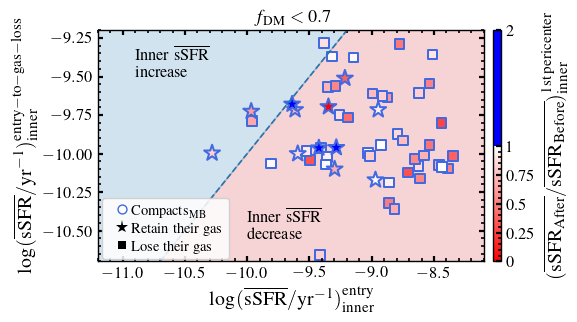

In [3]:
plot.PlotScatter(['MBCLoseTheirGas', 'MBCDontLoseTheirGas'], ['SatelliteDMpoor'], 'sSFRTrueInner_BeforeEntry', ['sSFRTrueInner_Entry_to_Nogas'],  Type='z0', snap=[99],
title=['DMpoor'], medianBins=False, medianAll=False, xlabelintext=False, All=None, GridMake = False, COLORBAR = ['sSFRRatioPericenter'],
               legend=True,LegendNames=[[ 'MBCEmptyScatter', 'DontLoseTheirGasColorbarScatter', 'LoseTheirGasColorbarScatter',]], TRANSPARENT = False,  
               cmap = 'bwr_r',
               alphaScater=1.,   alphaShade=0.3,  linewidth=1.2, 
               fontlabel=12.,
               m='o', msizet=3, quantile=0.95,framealpha = 0.85, q = 0.95,
               MarkerSizes = None,
               lNum = 3, cNum = 6,
               legpositions = [[0, 0]], 
               ylimmin = [-10.7], ylimmax = [-9.2],xlimmin = [-11.2], xlimmax = [-8.1],
               columnspacing = 0.001, handletextpad = -0.4, labelspacing = 0.3, loc = [(0.01, 0.01)],
               savepath='PaperII_NOSB/PlotScatter',  savefigname='sSFR_Check', dfName='PaperII', SampleName='Samples',
               bins=10, seed=16010504, mult = 4.1)

# Fig. 18


 Type:  SatelliteDMpoor
MBC


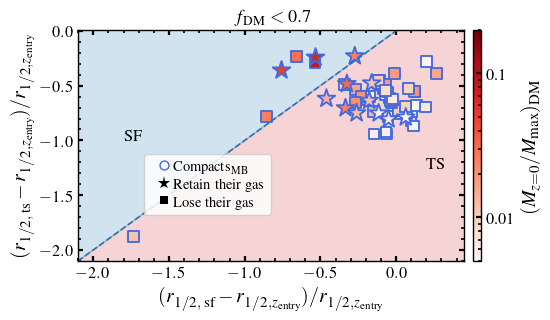

In [2]:
plot.PlotScatter(['MBCLoseTheirGas',  'MBCDontLoseTheirGas'], ['SatelliteDMpoor'], 'Relative_Rhalf_MaxProfile_Minus_HalfRadstar_Entry', 
                 ['Relative_Rhalf_MinProfile_Minus_HalfRadstar_Entry'],  Type='z0', snap=[99], COLORBAR = ['MDM_Norm_Max_99'],
title=['DMpoor'], medianBins=False, medianAll=False, xlabelintext=False, All=None, GridMake = False, 
               legend=True,LegendNames=[[ 'MBCEmptyScatter', 'DontLoseTheirGasColorbarScatter', 'LoseTheirGasColorbarScatter',]], TRANSPARENT = False,  
               cmap = 'Reds',
               alphaScater=1.,   alphaShade=0.3,  linewidth=1.2, 
               fontlabel=12,
               m='o', msizet=4.5, quantile=0.95,framealpha = 0.85, q = 0.95,
               ylimmin = [-2.1], ylimmax = [0.01],xlimmin = [-2.1], xlimmax = [0.45],
               MarkerSizes = None,
               lNum = 3, cNum = 6,
               legpositions = [[0, 0]],
               columnspacing = 0.5, handletextpad = -0.4, labelspacing = 0.3, loc = [(0.17, 0.2)],
               savepath='PaperII_NOSB/PlotScatter',  savefigname='Rhalf_New', dfName='PaperII', SampleName='Samples',
               bins=10, seed=16010504, mult = 4.1)

# Fig. 19

# Fig. 20

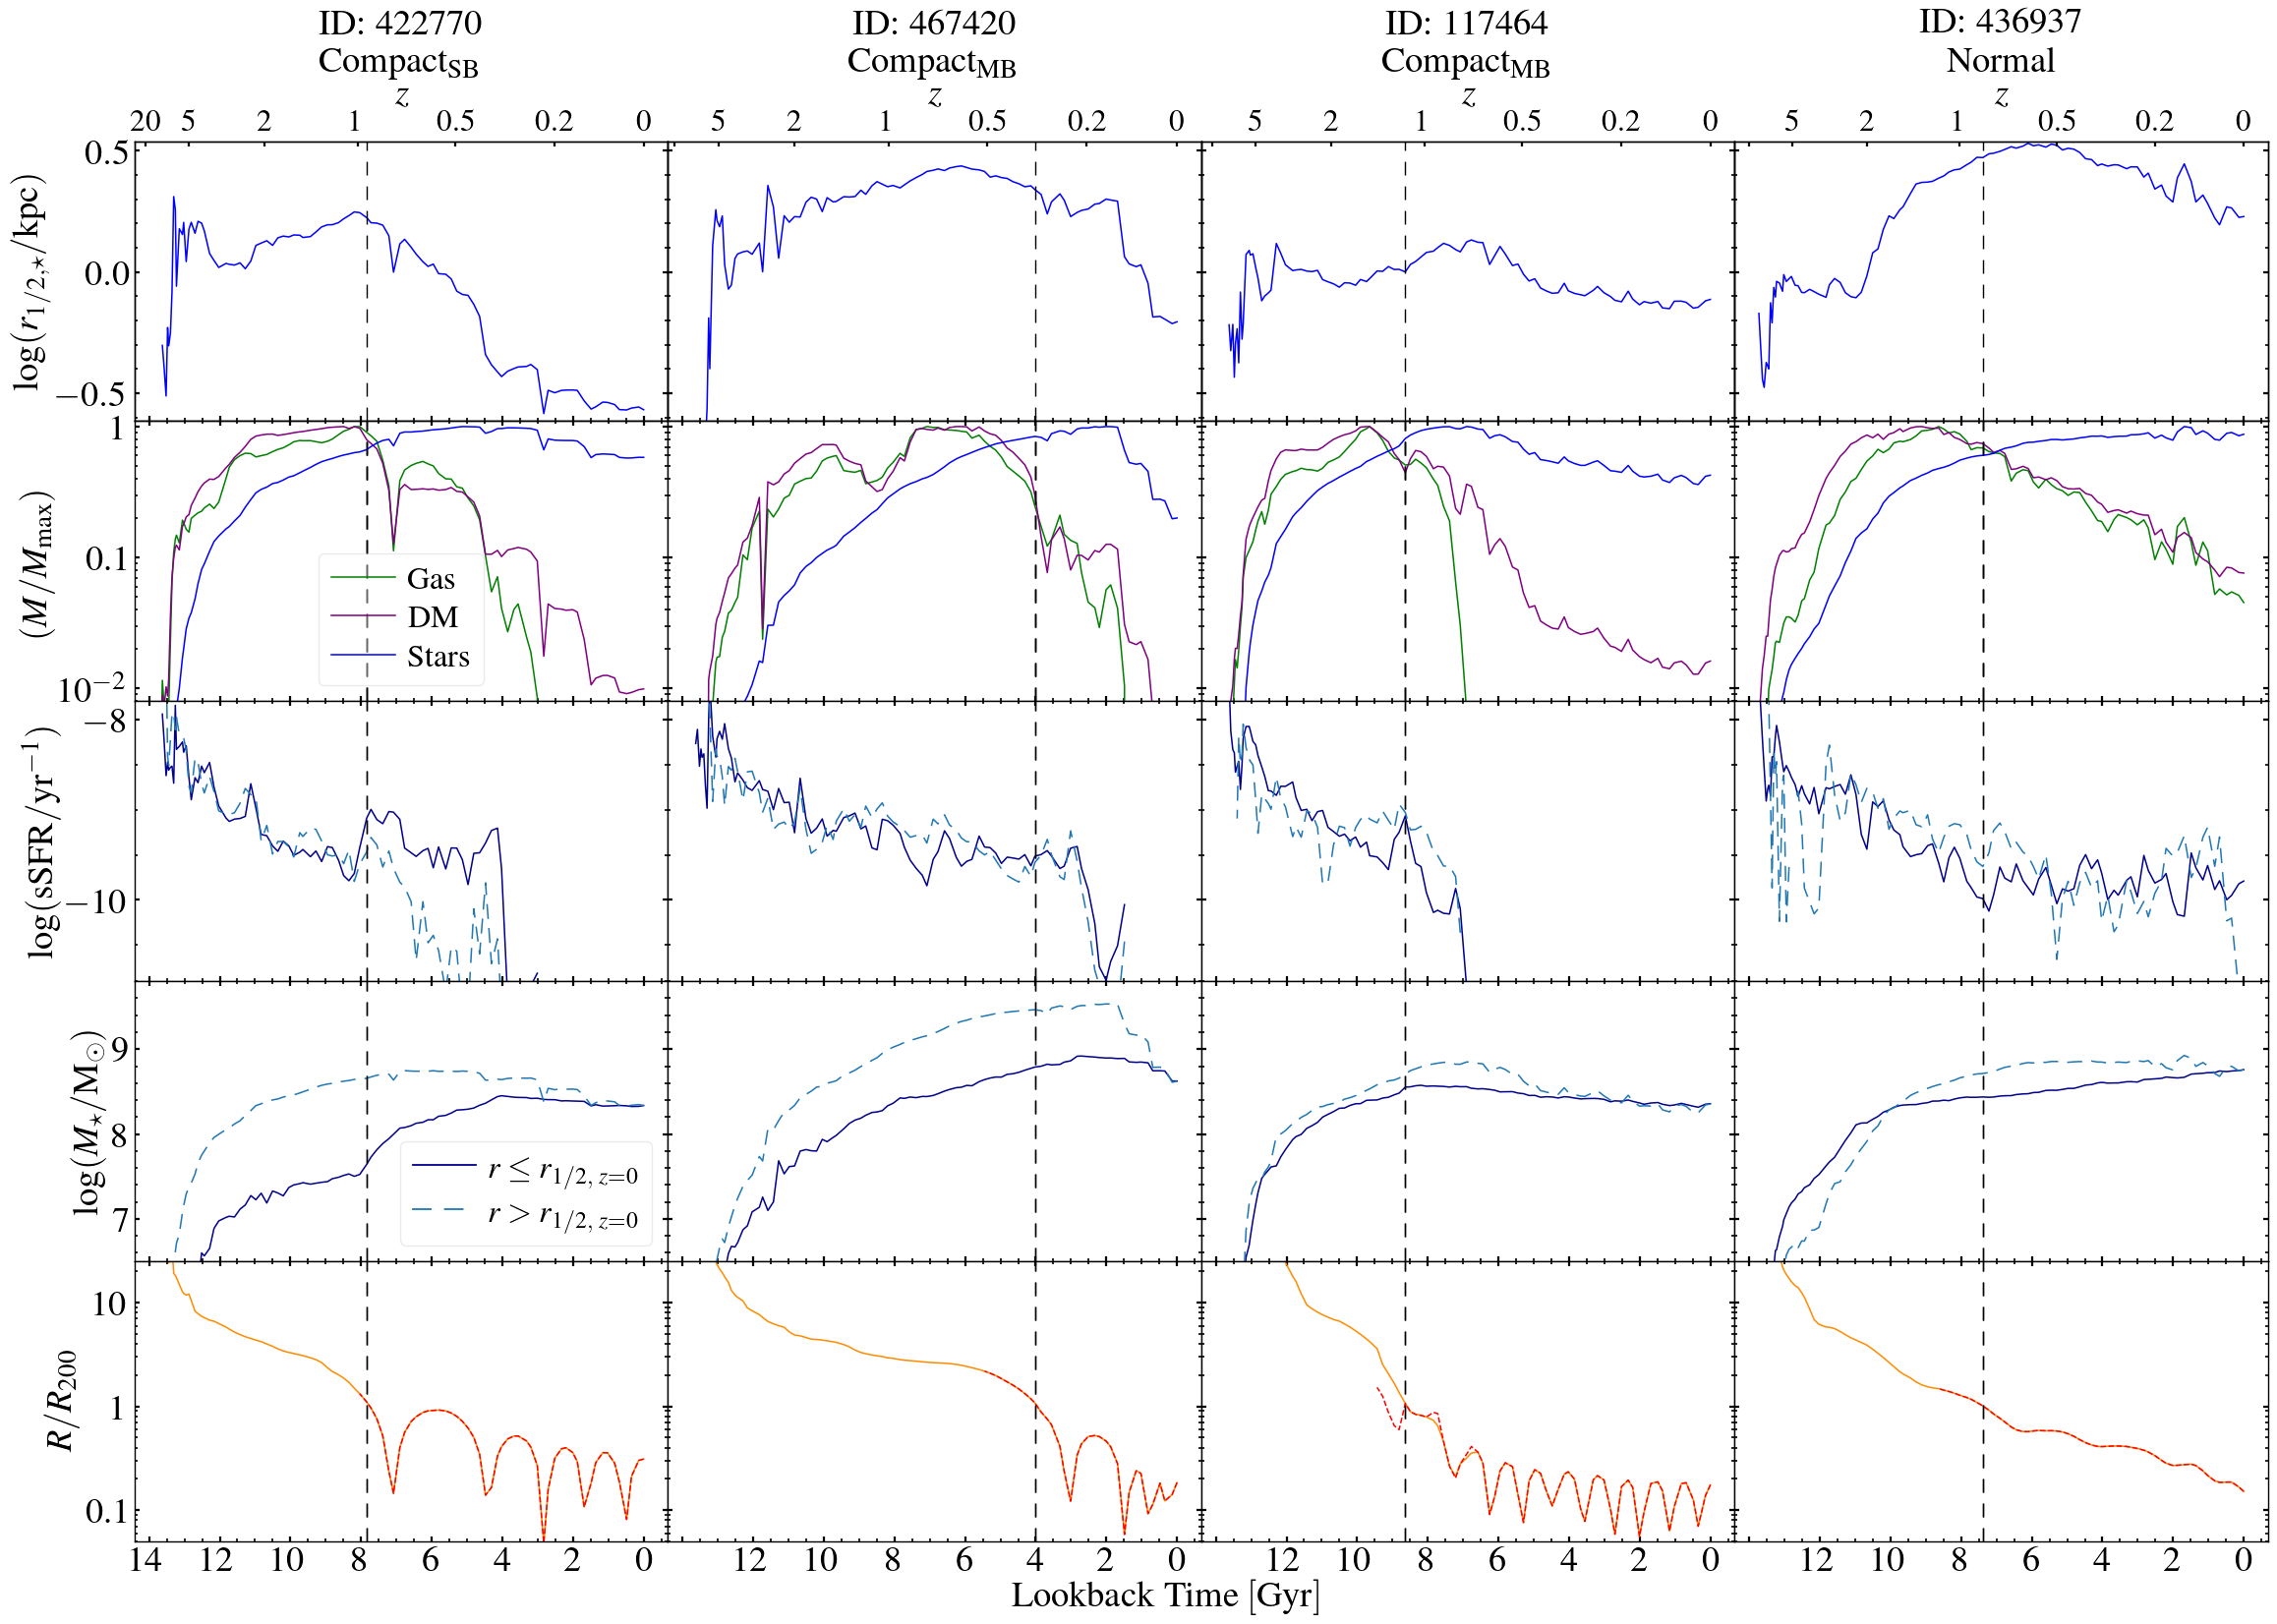

In [8]:
IDs = [422770, 467420, 117464, 436937]

IDsName = ['ID: 422770 \n Compact$_\mathrm{SB}$',  'ID: 467420 \n Compact$_\mathrm{MB}$', 'ID: 117464 \n Compact$_\mathrm{MB}$', 'ID: 436937 \n Normal']

plot.PlotIDsColumns(IDs, [[  'SubhaloHalfmassRadType4'],['Mgas_Norm_Max', 'MDM_Norm_Max', 'Mstar_Norm_Max'], 
                           ['sSFR_In_Rhpkpc', 'sSFR_Above_Rhpkpc'], 
                          ['StarMass_In_Rhpkpc', 'StarMass_Above_Rhpkpc'], ['r_over_R_Crit200', 'r_over_R_Crit200_FirstGroup']], dataMarker=None, dataLine=None,  
                  title=IDsName, xlabelintext=False, lineparams=False,  QuantileError=True, 
           alphaShade=0.3,  linewidth=1.1, fontlabel=26.5,  nboots=100,  ColumnPlot=False, limaxis=False, 
           columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3,  Pericenter = False, postext = ['best'],
           lNum = 7, cNum = 3.7,
           NoGas = False, InfallTime = True, GridMake = False,
           ylimmin = [ -0.615, 0.008, -10.9, 6.5, 0.05], ylimmax = [0.54, 1.1, -7.8,  9.8, 25],
           SmallerScale = True,
           Type='Evolution', Xparam='Time', savepath='PaperII/PlotIDColumns', savefigname='Cases_LIMITED', dfName='PaperII', SampleName='Samples',
             legend=True, LegendNames='None',  loc='best', LookBackTime = True,
           bins=10, seed=16010504, TRANSPARENT = False, Softening = False, MaxSizeType = False)

# Fig. 21

SatelliteDMrich: 0.9693355560302734
SatelliteDMpoor: 1.7243141348266606
Central: 0.4538936614990234


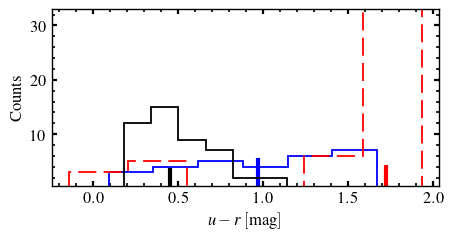

In [10]:
plot.PlotHist(['SatelliteDMrich', 'SatelliteDMpoor', 'Central'], [ 'MBC'],
              ['U-r'],   Type = 'Sample',
               savepath='PaperII_NOSB/PlotHist',  savefigname='Color', dfName='PaperII', SampleName='SubfindID_99', 
                density=False, 
                ColumnPlot = True, bins=[[6, 6, 6]], median=True,  legend = True,  legendColumn = True, GridMake = False,
                lNum = 2.3, cNum = 5, 
                LegendNames = [['SatelliteDMrich', 'SatelliteDMpoor', 'Central']], legpositions = [[1, 0]], loc = [(0.02, 0.665)],
                ylimmin = [0.4, 0.4], ylimmax = [33, 32], #xlimmin = [-0.1, 10.2, 0.08], xlimmax = [3.5, 14.9, 9],
                yscale = 'linear', TRANSPARENT = True, LookBackTime = True, 
                fontlabel=12, linewidth=1.3,
                framealpha=0.7, handlelength = 1.2, handletextpad = 0.25)



# Fig. 22

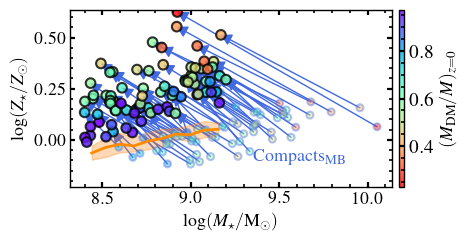

In [ ]:
#%%
fig = plt.figure()
plt.rcParams.update({'figure.figsize': (6, 2.6)})
gs = fig.add_gridspec(1, 1)
axs = gs.subplots()

cmap = plt.cm.get_cmap('rainbow_r')

Zsun = 0.0127 

MBCSatellite = TNG.extractPopulation('MBCSatellite')
NormalSatellite = TNG.extractPopulation('NormalSatellite')

XMBCMax = np.array([v for v in MBCSatellite.MaxStellarMassInRad[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values])
YMBC = np.log10(np.array([v for v in MBCSatellite.StarMetallicity_99[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values]) / Zsun)
XMBC = np.array([v for v in MBCSatellite.logMstarRad_99[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values])
YMBCMax = np.log10(np.array([v for v in MBCSatellite.MaxStarMetallicity[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values]) / Zsun)

XNormal = np.array([v for v in NormalSatellite.logMstarRad_99[(NormalSatellite.MaxStellarMassInRad != NormalSatellite.logMstarRad_99)].values])
YNormal = np.log10(np.array([v for v in NormalSatellite.StarMetallicity_99[(NormalSatellite.MaxStellarMassInRad != NormalSatellite.logMstarRad_99)].values]) / Zsun)

# Setas MBC
for i in range(len(XMBC)):
    if abs(XMBC[i] - XMBCMax[i]) > 0.05:
        prop = dict(arrowstyle="-|>,head_width=0.2,head_length=0.35",
                    color='royalblue', shrinkA=0, shrinkB=0)
        axs.annotate("", xy=(XMBC[i], YMBC[i]),
                     xytext=(XMBCMax[i], YMBCMax[i]),
                     arrowprops=prop, zorder=0)

# Binning dos Normal
num_bins = 10
bins = np.linspace(min(XNormal), max(XNormal), num_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

median_y = []
percentile_25 = []
percentile_75 = []

for i in range(num_bins):
    bin_y = YNormal[(XNormal >= bins[i]) & (XNormal < bins[i + 1])]
    median_y.append(np.median(bin_y))
    percentile_25.append(np.percentile(bin_y, 25))
    percentile_75.append(np.percentile(bin_y, 75))

median_y = np.array(median_y)
percentile_25 = np.array(percentile_25)
percentile_75 = np.array(percentile_75)

axs.plot(bin_centers, median_y, color='darkorange', lw=2)
axs.fill_between(bin_centers, percentile_25, percentile_75, color='tab:orange', alpha=0.3)

# Scatter MBC (máximo)
sc = axs.scatter(XMBCMax, YMBCMax,
                 c=MBCSatellite.DMFrac_99[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values,
                 edgecolor='royalblue', alpha=.4, lw=1.5,
                 marker='o', s=3.1*8, cmap=cmap)

# Scatter MBC (z=0)
sc = axs.scatter(XMBC, YMBC,
                 c=MBCSatellite.DMFrac_99[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values,
                 edgecolor='black', alpha=.8, lw=1.5,
                 marker='o', s=6*8, cmap=cmap)

cb = fig.colorbar(sc, ax=axs, pad=0.02, aspect=40)
cb.set_label(r'$(M_\mathrm{DM}/ M)_{z = 0}$', fontsize=13)

axs.set_xlabel('$\log(M_\star/\mathrm{M}_\odot)$', fontsize=13)
axs.set_ylabel(r'$\log( Z_\star / Z_\odot)$', fontsize=13)
axs.set_ylim(np.log10(0.0075 / Zsun), np.log10(0.055 / Zsun))
axs.tick_params(labelsize=0.99*13)

axs.text(9.35, -0.1, 'Compacts$_\mathrm{MB}$', fontsize=13, color='royalblue')

plt.savefig(os.getenv('HOME') + '/TNG_Analyzes/Figs/TNG50/PaperII_NOSB/PlotScatter/Zmetallicty_MBC.pdf',
            bbox_inches='tight')



# Fig. 23


 Type:  SatelliteDMpoor
MBC


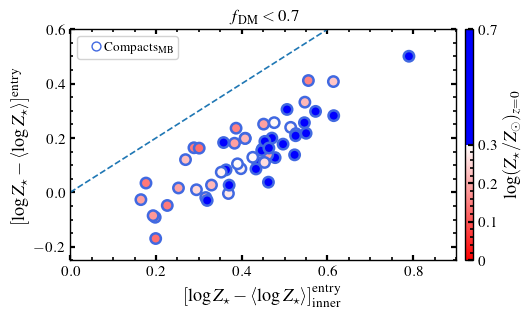

In [6]:
plot.PlotScatter(['MBC'], ['SatelliteDMpoor'], 'Relative_logInnerZ_At_Entry', 
                 ['Relative_logZ_At_Entry'],  Type='z0', snap=[99], COLORBAR = ['logStarZ_99'],
title=['DMpoor'], medianBins=False, medianAll=False, xlabelintext=False, All=None, GridMake = False, 
               legend=True,LegendNames=[[ 'MBCEmptyScatter']], TRANSPARENT = False,  
               cmap = 'bwr_r',
               alphaScater=1.,   alphaShade=0.3,  linewidth=1.2, 
               fontlabel=11,
               m='o', msizet=4.5, quantile=0.95,framealpha = 0.85, q = 0.95,
               ylimmin = [-0.25], ylimmax = [0.6],xlimmin = [0.0], xlimmax = [0.9],
               MarkerSizes = None,
               lNum = 3, cNum = 6,
               legpositions = [[0, 0]],
               columnspacing = 0.5, handletextpad = -0.4, labelspacing = 0.3, loc = ['best'],
               savepath='PaperII_NOSB/PlotScatter',  savefigname='ZEntry', dfName='PaperII', SampleName='Samples',
               bins=10, seed=16010504, mult = 4.1)

# Fig. A1


 Type:  Satellite


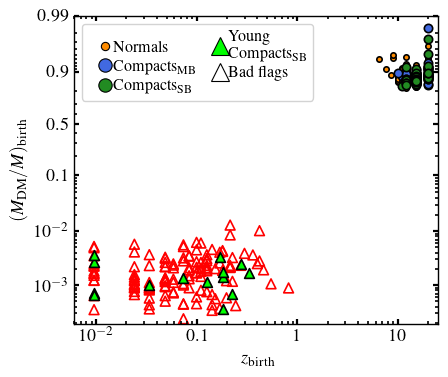

In [11]:
plot.PlotScatter(['Normal','MBC', 'SBC',  'BadFlag', 'SBCBornYoung'], ['Satellite'], 'z_Birth', 'DMFrac_Birth',  Type='z0', snap=[99],
 title=False, medianBins=False, medianAll=False, xlabelintext=False, All=None,
                legend=True, LegendNames=[['NormalBlackLineScatter', 'MBCBlackLineScatter', 'SBCBlackLineScatter', 'SBCBornYoungBlackLineScatter', 'BadFlagBlackLineScatter']],  TRANSPARENT = False, COLORBAR = None, medianDot = False, 
                alphaScater=1.,   alphaShade=0.3,  linewidth=1.2, 
                fontlabel=13.2,  
                m='o', msizet=4.5, quantile=0.95,framealpha = 0.85, q = 0.95,
                MarkerSizes = None, GridMake = False,
                lNum = 4, cNum = 4.7, 
                ylimmin = [1.9e-4], ylimmax = [0.99], xlimmin = [6e-3], xlimmax = [25],  
                legpositions = [[0, 0]],
                columnspacing = 0.5, handletextpad = -0.5, labelspacing = 0.3, loc = ['best'],
                savepath='PaperII/PlotScatter',  savefigname='BADFlag', dfName='PaperII', SampleName='Samples', cmap = 'inferno',
                bins=10, seed=16010504, mult = 4.1)


# Fig. A2

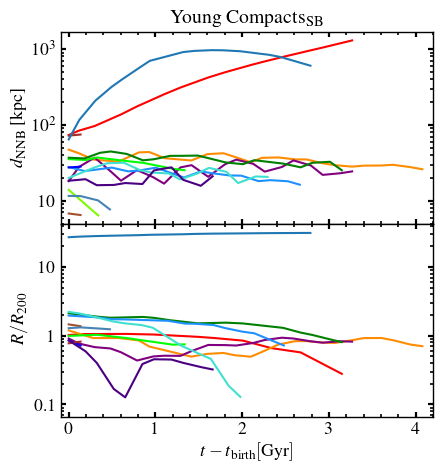

In [13]:
SBCYoungIDs = np.array([  327, 117361, 167459, 167466, 167504, 242823, 242824, 242825, 264957, 355743, 355744, 371132, 413377, 923816])
plot.PlotID(['SBCBornYoung'],  ['rToRNearYoung', 'r_over_R_Crit200'], [SBCYoungIDs], 
            Type = 'Evolution', Xparam = ['tsincebirth', 'tsincebirth']  ,
            savepath='PaperII/PlotID',  savefigname='Young', dfName='PaperII', SampleName='SubfindID_99',  LookBackTime = True,
            #ylimmin = [-0.62, -11.2, 0.1], ylimmax = [0.5, -7.8, 2.15], xlimmin = None, xlimmax = None,
            lNum = 2.5, cNum = 4.8, GridMake = False,
            ColumnPlot=False, limaxis=False, xlabelintext=False, TRANSPARENT = True, legend=False, title=['Young Compacts$_\mathrm{SB}$'], lineparams=False, 
            loc='best', QuantileError = False, linewidth = 1.5, fontlabel=13,  
            Softening = True, sSFRMedian = False)

# Fig. B1


[13.802819 13.666329 13.462742 13.327794 13.126561 12.993212 12.794419
 12.662724 12.466454 12.336469 12.142804 11.950741 11.823602 11.634269
 11.508976 11.32245  11.137642 11.015405 10.833517 10.653412 10.534345
 10.298646 10.182027 10.008651  9.837158  9.723884  9.555567  9.389178
  9.224732  9.062243  8.901722  8.743182  8.586632  8.432081  8.279538
  8.079279  7.93144   7.785623  7.641832  7.45326   7.314194  7.131918
  6.997566  6.821561  6.691897  6.522119  6.355871  6.193132  6.073364
  5.878068  5.725682  5.576682  5.43103   5.288689  5.115354  4.980306
  4.815949  4.656455  4.501729  4.292939  4.206193  4.037511  3.901735
  3.744403  3.593009  3.447374  3.284507  3.128954  2.980437  2.838681
  2.684607  2.538618  2.383569  2.237743  2.145398  1.944184  1.811915
  1.688509  1.540402  1.466045  1.365945  1.28166   1.177255  1.11239
  1.036282  0.965356  0.931726  0.843642  0.763859  0.732013  0.686709
  0.639645  0.595801  0.54713   0.516909  0.474674  0.417697  0.370175
  0.270

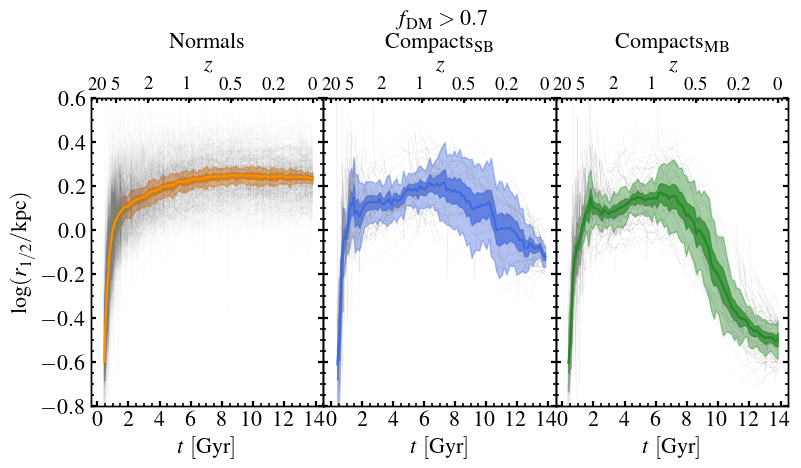

In [14]:
plot.PlotIDsAllTogether(['NormalSatelliteDMrich','MBCSatelliteDMrich', 'SBCSatelliteDMrich'],['SubhaloHalfmassRadType4'],ylimmin = [-0.8], ylimmax = [0.6], title = ['Normals', '$f_\mathrm{DM} > 0.7$ \n Compacts$_\mathrm{SB}$', 'Compacts$_\mathrm{MB}$'], MedianPlot = True,
lNum = 4, cNum = 3, ColorMaps = [plt.get_cmap('Oranges'), plt.get_cmap('Blues'), plt.get_cmap('Greens')],
alphaShade=0.3,  linewidth=1.1,  fontlabel=16,  nboots=100,  
 columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3, 
bins=10, seed=16040105, savepath='fig/PlotIDsAllTogether', savefigname='RandomLines',
dfName='PaperII')

# Fig. C1


 Type:  SatelliteDMpoor


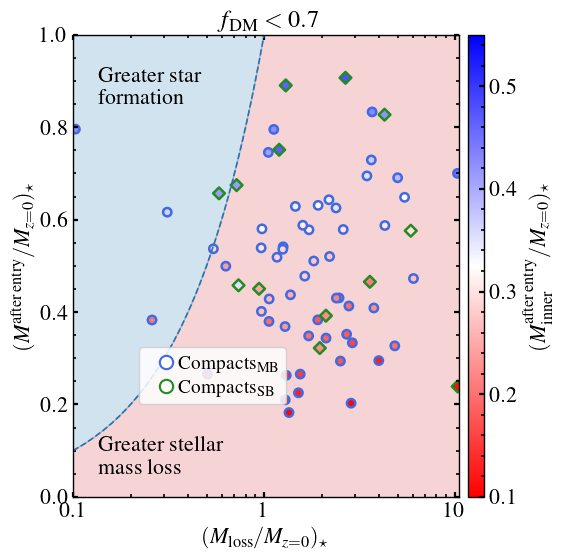

In [15]:
plot.PlotScatter(['MBC', 'SBC'], ['SatelliteDMpoor'], 'FracStarLoss', 
                 ['FracStarAfterEntry'],  Type='z0', snap=[99], COLORBAR = ['FracStarAfterEntry_Inner'],
title=['DMpoor'], medianBins=False, medianAll=False, xlabelintext=False, All=None, GridMake = False, 
               legend=True,LegendNames=[[ 'MBCEmptyScatter', 'SBCEmptyScatter']], TRANSPARENT = False,  
               cmap = 'bwr_r',
               alphaScater=1.,   alphaShade=0.3,  linewidth=1.2, 
               fontlabel=16,
               m='o', msizet=4.5, quantile=0.95,framealpha = 0.85, q = 0.95,
               ylimmin = [0.], ylimmax = [1.],xlimmin = [0.1], xlimmax = [10.5],
               MarkerSizes = None,
               lNum = 6, cNum = 6,
               legpositions = [[0, 0]],
               columnspacing = 0.5, handletextpad = -0.4, labelspacing = 0.3, loc = [(0.17, 0.2)],
               savepath='PaperII/PlotScatter',  savefigname='FracLoss', dfName='PaperII', SampleName='Samples',
               bins=10, seed=16010504, mult = 4.1)

# Fig. E1

IDs = np.array([63990, 64002, 96853, 117357, 229992, 294887, 294895])
IDsName = [str(i) for i in IDs]

plot.PlotIDsColumns(IDs, [['SubhaloHalfmassRadType0', 'SubhaloHalfmassRadType1', 'SubhaloHalfmassRadType4'], ['Mgas_Norm_Max', 'MDM_Norm_Max', 'Mstar_Norm_Max'], 
                           ['sSFR_In_Rhpkpc', 'sSFR_Above_Rhpkpc'], 
                          ['StarMass_In_Rhpkpc', 'StarMass_Above_Rhpkpc'], ['r_over_R_Crit200', 'r_over_R_Crit200_FirstGroup']], dataMarker=None, dataLine=None,  
                  title=IDsName, xlabelintext=False, lineparams=False,  QuantileError=True, 
           alphaShade=0.3,  linewidth=1.1, fontlabel=26.5,  nboots=100,  ColumnPlot=False, limaxis=False, 
           columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3,  Pericenter = False, postext = ['best'],
           lNum = 7, cNum = 3.7, PhasingPlot = True,
           NoGas = False, InfallTime = True, GridMake = False,
           ylimmin = [-0.62, 0.008, -10.9, 6.5, 0.05], ylimmax = [1.65, 1.1, -7.8,  10.1, 25],
           SmallerScale = True,
           Type='Evolution', Xparam='Time', savepath='PaperII/PlotIDColumns', savefigname='test', dfName='PaperII', SampleName='Samples',
             legend=True, LegendNames='None',  loc='best', LookBackTime = True,
           bins=10, seed=16010504, TRANSPARENT = False, Softening = False, MaxSizeType = False)